# RQ1_new — claims analysis

One table and/or figure per thesis claim (0 through 6), each followed by a written interpretation stating whether the evidence confirms, rejects, or leaves the claim's expectation open. This notebook exists specifically to back the claims-table slide for supervisor updates -- every row in that table should be traceable to something here.

Reads from `clean_data/<model>.csv` (curated, `ROUND_STATUS`-filtered, built by `build_clean_dataset.py`) via `analysis_lib.py`'s `load_model`/`load_model_both`. Rerun `build_clean_dataset.py` after collecting or merging new rounds, then re-execute this notebook, before trusting numbers here against a live meeting.

For the broader exploratory analysis (data quality, per-model distributions, matmul-vs-primes comparison) see `analysis_notebook.ipynb` -- that notebook now covers Sections A through C only; this one is Section D, split out on its own since it has a different audience and purpose (evidence pack, not exploration).

In [1]:
import sys

sys.path.append("/home/silvia/Documents/GraduationProject/research-questions/RQ1_new/analysis")

import analysis_lib as al
import pandas as pd
pd.set_option("display.width", 140)

MODELS = ["model1", "model3", "model3-w2", "model3-w3", "model3-w4"]  # model2 excluded: no joined files built
KINDS = ["matmul", "primes"]  # primes replaced ptrchase 2026-08-14 -- see backlog

# data[(model, kind)] -- single-workload frame, used by every per-workload
# section below so R/C distributions of two different workloads never get
# pooled together by accident (they use different reservation sizes/K
# calibration and aren't comparable as one blended sample).
data = {(m, k): al.load_model(m, kind=k) for m in MODELS for k in KINDS}

# data_both[model] -- both kinds together (kind column intact), used only by
# Section C's direct matmul-vs-primes comparison.
data_both = {m: al.load_model_both(m) for m in MODELS}

### Claim 0 — the Azure IaaS noise floor
Even the solo baseline (model1, zero explicit contention) should show some non-zero variance from hypervisor/OS jitter alone. Expectation: small, and small relative to the degradation seen once real contention is introduced (Claims 2/4/5). Evidence: coefficient of variation (std/mean) of C and R, solo baseline, both workload kinds.

In [2]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    print(f"=== model1 ({k}) ===")
    display(al.noise_floor_table(df))

=== model1 (matmul) ===


,scale,U,metric,mean_ms,std_ms,cv
0,soft,0.10,C,7.256,0.204,0.0281
1,soft,0.10,R,7.421,2.394,0.3227
2,soft,0.20,C,14.205,0.208,0.0147
3,soft,0.20,R,14.227,0.217,0.0152
4,soft,0.30,C,21.627,0.445,0.0206
5,soft,0.30,R,21.667,1.007,0.0465
6,soft,0.40,C,28.235,0.412,0.0146
7,soft,0.40,R,28.349,0.412,0.0145
8,soft,0.50,C,35.659,0.923,0.0259
9,soft,0.50,R,35.758,1.258,0.0352


^ model1 (matmul)


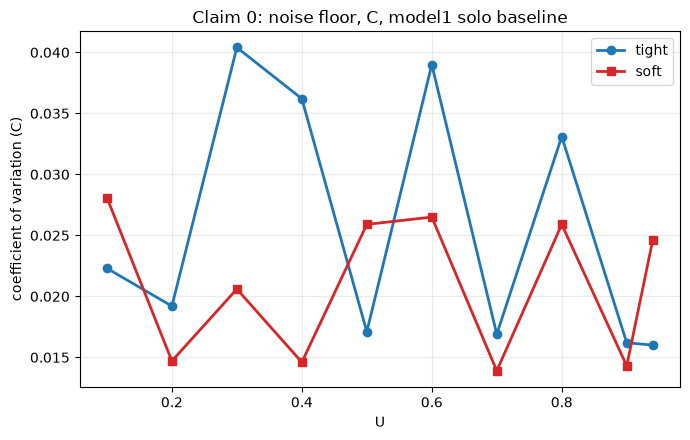

In [3]:
for k in KINDS:
    df = data[("model1", k)]
    if df.empty: continue
    al.plot_noise_floor(df, metric="C")
    print(f"^ model1 ({k})")

**Interpretation: confirmed, matmul only for now — primes has no valid round to check yet.** Coefficient of variation is the right measure here because it normalizes out the fact that different utilization levels have wildly different absolute execution times (a few hundred microseconds at U=0.1 versus tens of milliseconds at U=0.9) -- without normalizing, we would just be comparing noise at different scales and drawing the wrong conclusions. C's coefficient of variation sits in a tight 0.014 to 0.05 band across essentially every scale and utilization in the matmul baseline. That is the actual internal noise floor of this setup: the amount of run-to-run variability you get from hypervisor scheduling jitter and OS-level effects alone, with no explicit contention introduced at all, since model1 is the solo baseline.

R's coefficient of variation looks much larger in a handful of tight-scale, low-utilization cells (up to 0.28 at tight U=0.1). This is not evidence of worse instability -- it is an artifact of how coefficient of variation behaves when the underlying mean is very small. At low utilization on the tight scale, the response time R is only a few hundred microseconds on average, so a handful of naturally occurring outlier jobs (a slightly delayed wakeup, a stray scheduling event) get divided by that tiny mean and produce a large ratio, even though the absolute size of those outliers is trivial in real terms. C does not suffer from this same distortion because it measures pure execution time, which is far less sensitive to the occasional wakeup delay that inflates R. So C is the cleaner, more trustworthy signal for this specific claim, and it stays small and essentially flat across the entire sweep, exactly what you would expect from a workload with no real contention imposed on it.

**Data gap worth flagging rather than glossing over:** `results/model1_primes_round1` exists on disk but every one of its 20 cells is stamped `kind=matmul` in the probe's own CSV header -- it's a mislabeled leftover, not real primes data, and was deliberately left out of `ROUND_STATUS` rather than silently pooled in. So this specific claim (the baseline noise floor) currently has no primes-side number to report, even though primes data is now valid and pooled for model3's whole family (Claims 1 through 5 below). Worth collecting a real `model1` primes round before the final writeup, since primes' own noise floor is expected to be substantially higher on general principle (its per-job cv, measured directly on the sibling-arm data, sits around 0.1-0.3 rather than matmul's 0.02-0.05, because trial-division's early-exit branching makes execution time genuinely data-dependent even with zero contention) -- but that number needs its own solo-baseline measurement, not an assumption carried over from the contended arms.

This number matters for every claim that follows: any degradation reported elsewhere in this notebook needs to be large relative to this 0.02 to 0.05 matmul baseline to be credible as a real effect rather than measurement noise, and as the later claims show, the degradation found is one to two orders of magnitude larger than this floor.

### Claim 1 — does reservation alone protect against SMT sharing
model2 itself has no valid data (every round predates the liveness fix, post-fix rounds never collected). Answered instead via model3-w2 (sibling placement, reserved competitor), which tests the identical question at reservation size m=2 -- see the claims table note. Expectation: two properly reserved, admission-controlled workloads should still be able to violate each other's guarantees if they share a physical core, since admission accounting is per logical cpu, not per physical core. Evidence: per-round miss rate breakdown -- if even one round shows a cell crossing from near-0% to high miss while the reservation was verified correctly bounded, that is a violation despite correct admission control.

In [4]:
for m in ["model3-w2", "model3"]:
    for k in KINDS:
        t = al.round_stability_table(m, kind=k)
        if t.empty: continue
        miss_cols = [c for c in t.columns if not str(c).startswith("C_p50")]
        print(f"=== {m} ({k}) ===")
        display(t[miss_cols])

=== model3-w2 (matmul) ===


model3-w2_round1  model3-w2_round2  model3-w2_round3  model3-w2_round4
scale U                                                                           
soft  0.10            0.0000            0.0000            0.0000            0.7394
      0.20            0.0000            0.0000            1.0000            0.0002
      0.30            0.0000            0.0000            0.0006            0.0000
      0.40            0.0002            0.0000            0.0000            0.0002
      0.50            0.0000            0.0000            0.0000            0.0000
      0.60            0.0000            0.0000            0.0002            0.0000
      0.70            0.0000            0.0000            0.0000            0.0000
      0.80            0.0000            0.0000            0.0000            0.0000
      0.90            0.0000            0.0000            0.0000            0.0000
      0.94            0.0000            0.0000            0.0000            0.0000
tight 0.10            0.0046            0.0020            0.0008            0.0004
      0.20            0.0022            0.0120            0.0004            0.0008
      0.30            0.0030            0.0024            0.0006            0.0000
      0.40            0.0010            1.0000            0.0002            0.0000
      0.50            0.0004            1.0000            0.0006            0.0000
      0.60            0.0006            1.0000            0.0000            0.0000
      0.70            0.0000            1.0000            0.0004            0.0000
      0.80            0.0008            1.0000            0.0000            0.0000
      0.90            0.0006            1.0000            0.0004            0.0000
      0.94            0.0014            1.0000            0.0000            0.0000

=== model3-w2 (primes) ===


model3-w2_sib_res_primes_round1  model3-w2_sib_res_primes_round2  model3-w2_sib_res_primes_round3  \
scale U                                                                                                         
soft  0.10                           0.0002                           1.0000                           0.0006   
      0.20                           1.0000                           0.0000                           0.0000   
      0.30                           0.0000                           0.0000                           0.0004   
      0.40                           0.0000                           0.0000                           0.0000   
      0.50                           1.0000                           0.0532                           0.0000   
      0.60                           0.0000                           1.0000                           0.0000   
      0.70                           0.0000                           0.0000                           0.0016   
      0.80                           0.0000                           0.0000                           0.0006   
      0.90                           0.0000                           0.0000                           0.0002   
      0.94                           0.0000                           0.0002                           0.0000   
tight 0.10                           0.0880                           0.1070                           1.0000   
      0.20                           0.0002                           0.0000                           1.0000   
      0.30                           0.0000                           0.9968                           1.0000   
      0.40                           0.0000                           0.0000                           1.0000   
      0.50                           0.0002                           0.0000                           0.0000   
      0.60                           1.0000                           0.0000                           0.0012   
      0.70                           0.0000                           0.8020                           0.0000   
      0.80                           0.7308                           0.0000                           0.0000   
      0.90                           0.0020                           0.0000                           0.0000   
      0.94                           0.0008                           0.0000                           0.0000   

            model3-w2_sib_res_primes_round4  
scale U                                      
soft  0.10                           1.0000  
      0.20                           0.0000  
      0.30                           0.0000  
      0.40                           0.0000  
      0.50                           1.0000  
      0.60                           1.0000  
      0.70                           0.0000  
      0.80                           0.0000  
      0.90                           0.0000  
      0.94                           0.0002  
tight 0.10                           0.0366  
      0.20                           0.9996  
      0.30                           0.9718  
      0.40                           0.0000  
      0.50                           0.0000  
      0.60                           0.0000  
      0.70                           0.9996  
      0.80                           0.0000  
      0.90                           0.0000  
      0.94                           0.0032

=== model3 (matmul) ===


model3_round1  model3_round2  model3_round3  model3_round4
scale U                                                               
soft  0.10         0.0014         0.0000         0.0002         0.0446
      0.20         1.0000         0.0002         0.0000         0.9954
      0.30         0.0002         1.0000         0.0000         0.9974
      0.40         0.9994         0.0000         0.0000         0.0000
      0.50         1.0000         0.0000         0.0000         0.9946
      0.60         0.0062         0.0020         0.0000         0.0002
      0.70         0.0000         1.0000         0.0000         0.0000
      0.80         0.0186         0.0100         0.0000         0.0294
      0.90         0.0030         0.0034         0.0000         0.0060
      0.94         0.0002         0.0000         0.0000         0.0036
tight 0.10         0.0334         0.0406         0.0092         0.0152
      0.20         0.0050         0.0010         0.0122            NaN
      0.30         0.9624         0.0006         0.0014         0.0082
      0.40         0.0066         0.0020         0.0022         0.0186
      0.50         0.4008         1.0000         0.0024         0.0144
      0.60         1.0000         0.0500         0.0004         0.9922
      0.70         1.0000         0.0046         0.0012         0.0230
      0.80         0.7802         0.7520         0.0002         0.0290
      0.90         0.0386         0.0030         0.0006         0.0158
      0.94         0.0120         0.0040            NaN         0.0126

=== model3 (primes) ===


model3_sib_cfs_primes_round1  model3_sib_cfs_primes_round2  model3_sib_cfs_primes_round3  model3_sib_cfs_primes_round4
scale U                                                                                                                           
soft  0.10                        0.0004                        1.0000                        0.0014                        0.0124
      0.20                        0.0000                        0.0190                        0.0004                        0.0008
      0.30                        0.0018                        0.0578                        0.0000                        0.0000
      0.40                        0.0006                        0.1496                        0.0016                        0.0000
      0.50                        0.0004                        0.0022                        0.0000                        0.9900
      0.60                        0.0032                        1.0000                        1.0000                        1.0000
      0.70                        0.1054                        0.0448                        1.0000                        0.0010
      0.80                        0.0266                        0.0044                        0.0006                        1.0000
      0.90                        0.0114                        0.2216                        0.0104                        0.0208
      0.94                        0.0008                        0.1576                        0.0000                        0.0046
tight 0.10                        0.6124                        0.0942                        0.0088                        0.0050
      0.20                        0.0756                        0.0710                        0.1742                        0.9676
      0.30                        0.9998                        0.1192                        0.0040                        0.9926
      0.40                        0.2910                        0.1508                        0.0048                        0.0072
      0.50                        0.0074                        0.0716                        0.9946                        0.0270
      0.60                        0.0294                        0.1662                        0.0108                        0.0078
      0.70                        0.0180                        0.0072                        0.9966                        0.0128
      0.80                        0.1204                        0.9956                        0.9984                        0.0120
      0.90                        0.3018                        0.0418                        0.2698                        0.0126
      0.94                        0.0342                        0.0164                        0.0140                        0.1118

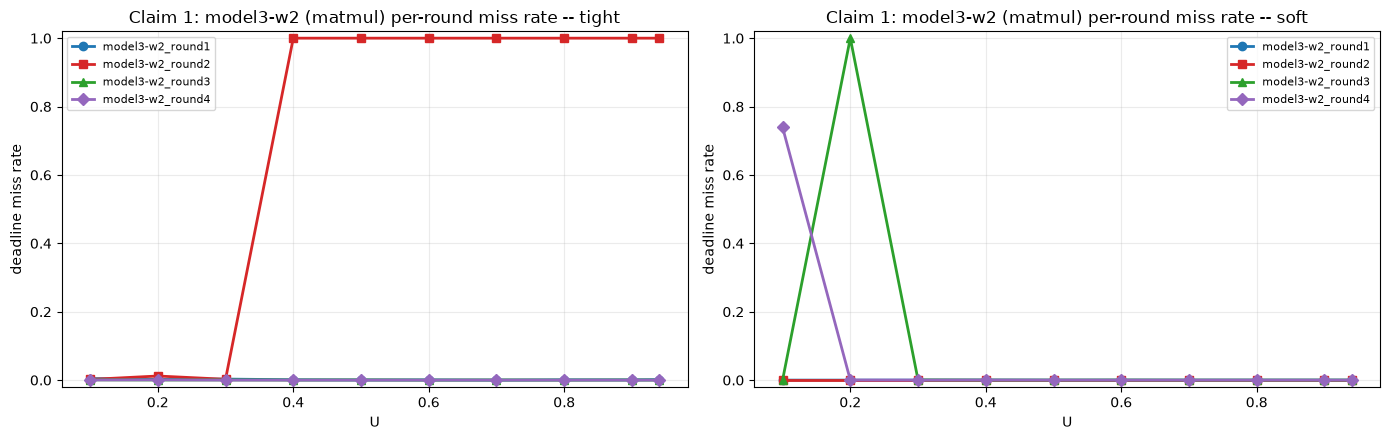

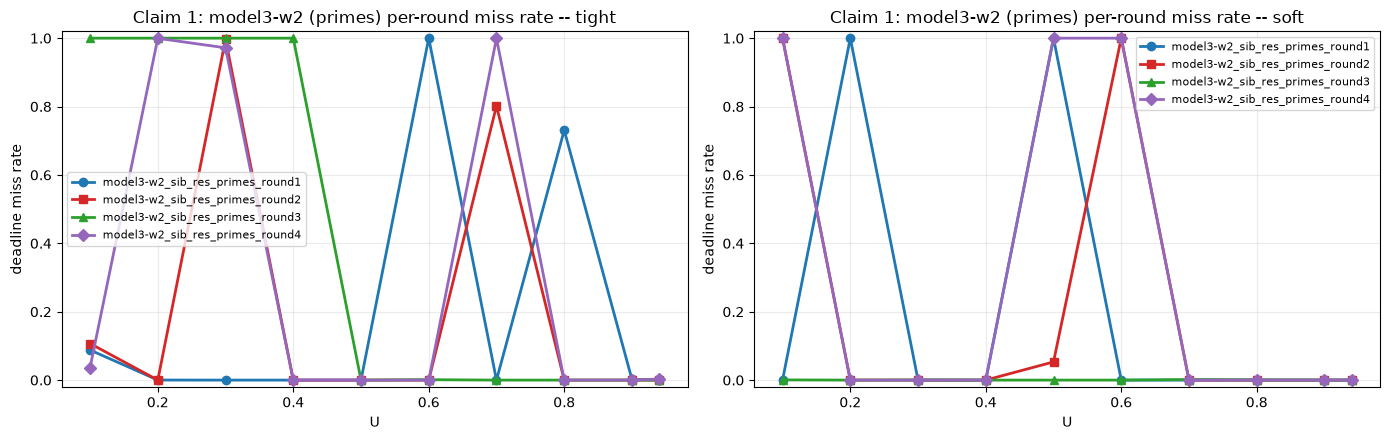

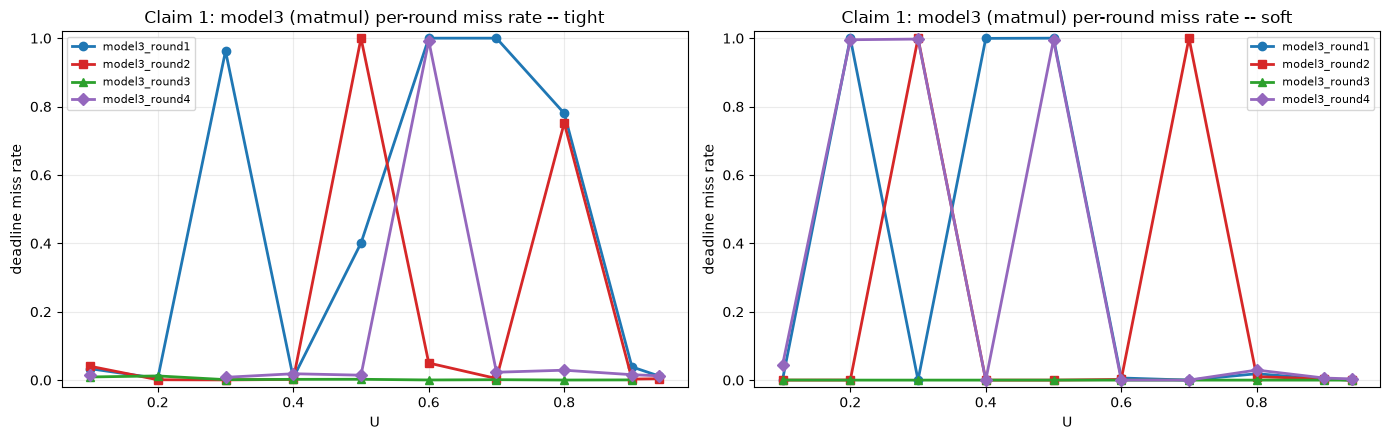

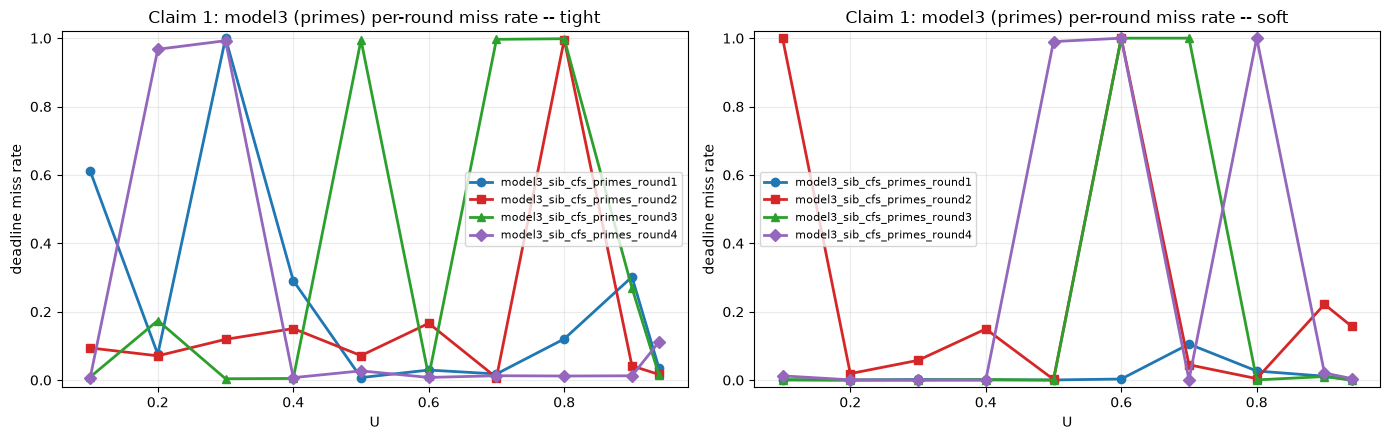

In [5]:
for m in ["model3-w2", "model3"]:
    for k in KINDS:
        fig = al.plot_round_stability(m, kind=k)
        if fig is None: continue

**Interpretation: confirmed, and primes makes the violation dramatically more visible than matmul ever did.** Four combinations here, all genuinely testing CBS admission control under physical-core sharing:

- **model3-w2, matmul, reserved competitor:** one of four rounds (round2) shows sustained near-total miss from tight scale U=0.4 all the way through U=0.94, while the other three rounds stay clean across that same range. One round out of four, but once it happens, it is a large and sustained failure, not a brief blip.
- **model3-w2, primes, reserved competitor:** every single one of the four rounds shows multiple cells crossing to near-total miss, scattered across different utilization values each time -- round1 at soft U=0.1/0.5, tight U=0.8; round2 at soft U=0.1/0.5/0.6, tight U=0.3/0.7; round3 at tight U=0.1/0.2/0.3/0.4; round4 at soft U=0.1/0.5/0.6, tight U=0.2/0.3/0.7. Not one bad round out of four -- four bad rounds out of four, each with a different, unpredictable set of affected cells.
- **model3, matmul, unreserved competitor:** three of the four rounds show repeated spikes scattered across many different utilization values rather than one contiguous stretch. Only round3 stays fully clean throughout.
- **model3, primes, unreserved competitor:** same pattern as model3-w2's primes data -- every round shows scattered high-miss cells at different U values (round1 at tight U=0.1/0.3; round2 at soft U=0.1/0.6; round3 at soft U=0.6/0.7; round4 at soft U=0.5/0.6/0.8, tight U=0.2/0.3), no round staying clean the way matmul's round3 did.

Why does a properly reserved, admission-controlled competitor still cause this at all? Because H-CBS admission accounting operates per logical cpu, not per physical core. When the target and its sibling competitor are admitted, the kernel checks that each one individually fits its own declared runtime and period, but it has no concept that the two logical cpus it just approved happen to share the same physical execution hardware underneath. Two reservations can each be perfectly valid on paper and still compete for the same execution ports the moment they actually run concurrently on sibling threads.

Why is primes so much more consistently affected than matmul? Because primes' own execution time is already data-dependent and noisier even with zero contention (per-job cv around 0.1-0.3, against matmul's 0.02-0.05, from the trial-division kernel's genuine early-exit branching). Sibling contention inflates C on top of that pre-existing spread, so the combined distribution straddles the alpha=1 cliff far more often, in far more cells, than a workload whose own execution time barely moves round to round. Matmul needed a genuinely bad round to show the effect; primes shows it almost everywhere, because it starts closer to the edge before contention is even added. That is not a weaker or noisier result -- it is a *stronger* demonstration of the same underlying gap, since it shows the failure mode is not a rare coincidence requiring an unlucky round, but the default behavior of any workload whose execution time has real intrinsic variance once it shares a physical core with another reservation.

### Claim 2 — decomposing where the guarantee breaks down (the 2x2)
Expectation: physical-placement arms (model3-w3, model3-w4) should look clean regardless of competitor type, since there is no shared execution-port resource once the pair is on separate physical cores. Sibling-placement arms (model3, model3-w2) should degrade, more so for an unreserved competitor than a reserved one. Evidence: miss rate and alpha side by side across all four arms, same workload kind, plus the same comparison as a figure.

In [6]:
ARMS = ["model3", "model3-w2", "model3-w3", "model3-w4"]
for k in KINDS:
    t = al.arm_comparison_table(ARMS, kind=k)
    if t.empty: continue
    print(f"=== {k} ===")
    display(t)

=== matmul ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.740,0.838,0.704,0.720,0.011550,0.18485,0.00000,0.001600
1,soft,0.20,0.949,0.715,0.701,0.725,0.498900,0.25005,0.00005,0.000400
2,soft,0.30,0.942,0.728,0.706,0.724,0.499400,0.00015,0.00000,0.000100
3,soft,0.40,0.731,0.807,0.700,0.726,0.249850,0.00010,0.00000,0.001050
4,soft,0.50,0.928,0.772,0.716,0.724,0.498650,0.00000,0.00000,0.000000
5,soft,0.60,0.859,0.711,0.719,0.723,0.002100,0.00005,0.00000,0.005100
6,soft,0.70,0.752,0.820,0.706,0.724,0.250000,0.00000,0.00000,0.000850
7,soft,0.80,0.972,0.799,0.701,0.722,0.014500,0.00000,0.00000,0.000850
8,soft,0.90,0.942,0.796,0.720,0.724,0.003100,0.00000,0.00000,0.000650
9,soft,0.94,0.798,0.797,0.707,0.723,0.000950,0.00000,0.00000,0.000850


=== primes ===


,scale,U,alpha_model3,alpha_model3-w2,alpha_model3-w3,alpha_model3-w4,miss_model3,miss_model3-w2,miss_model3-w3,miss_model3-w4
0,soft,0.10,0.743,1.084,0.703,0.695,0.25355,0.50020,0.00000,0.00005
1,soft,0.20,0.708,0.702,0.702,0.712,0.00505,0.25000,0.00000,0.00000
2,soft,0.30,0.698,0.741,0.716,0.705,0.01490,0.00010,0.00000,0.00000
3,soft,0.40,0.744,0.701,0.712,0.711,0.03795,0.00000,0.00000,0.00000
4,soft,0.50,0.703,1.044,0.710,0.708,0.24815,0.51330,0.00000,0.00000
5,soft,0.60,1.157,0.991,0.702,0.713,0.75080,0.50000,0.00000,0.00000
6,soft,0.70,0.937,0.792,0.707,0.717,0.28780,0.00040,0.00005,0.00000
7,soft,0.80,0.865,0.787,0.716,0.713,0.25790,0.00015,0.00000,0.00000
8,soft,0.90,0.988,0.770,0.714,0.709,0.06605,0.00005,0.00000,0.00000
9,soft,0.94,0.967,0.898,0.704,0.711,0.04075,0.00010,0.00000,0.00000


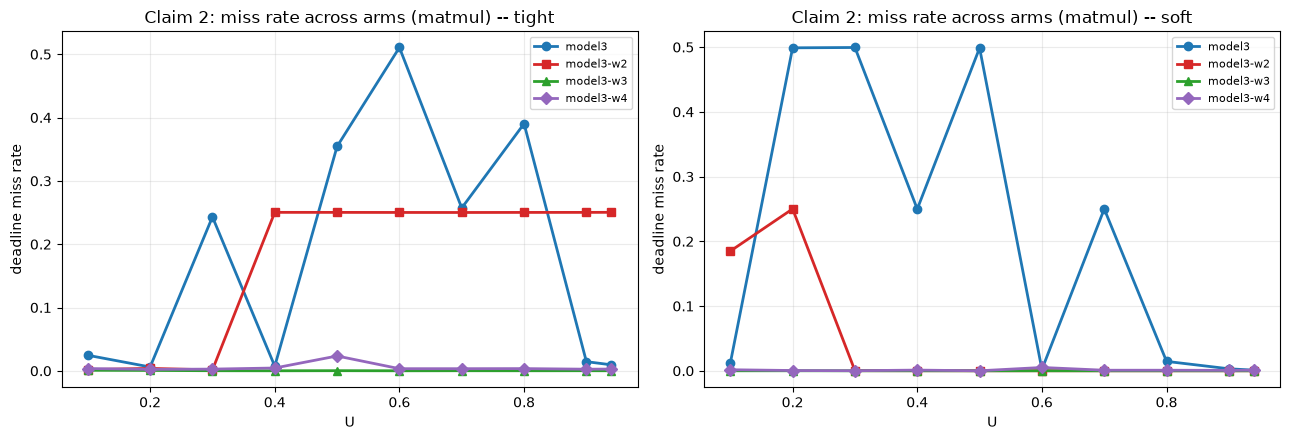

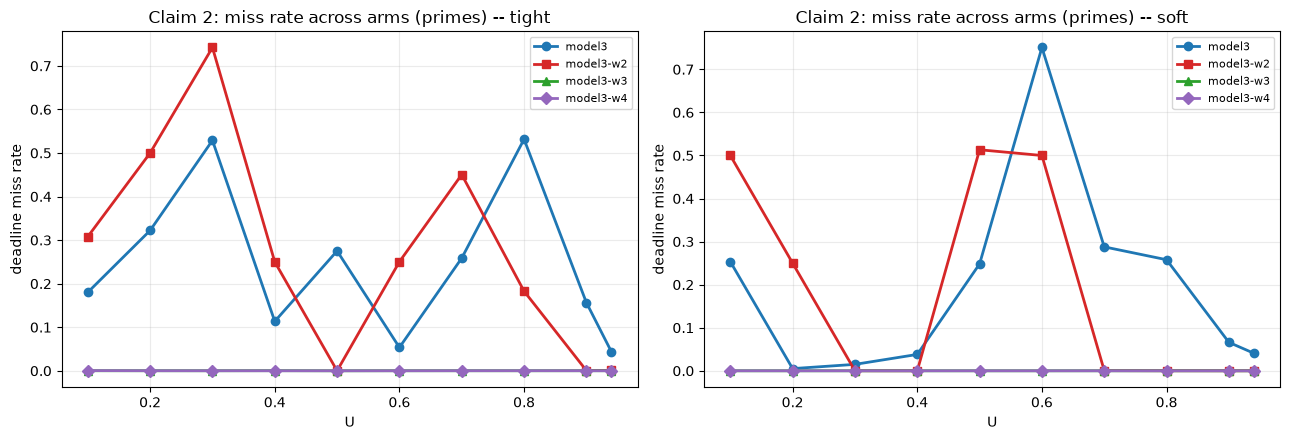

In [7]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "deadline_miss", "deadline miss rate", f"Claim 2: miss rate across arms ({k})")
    if fig is None: continue

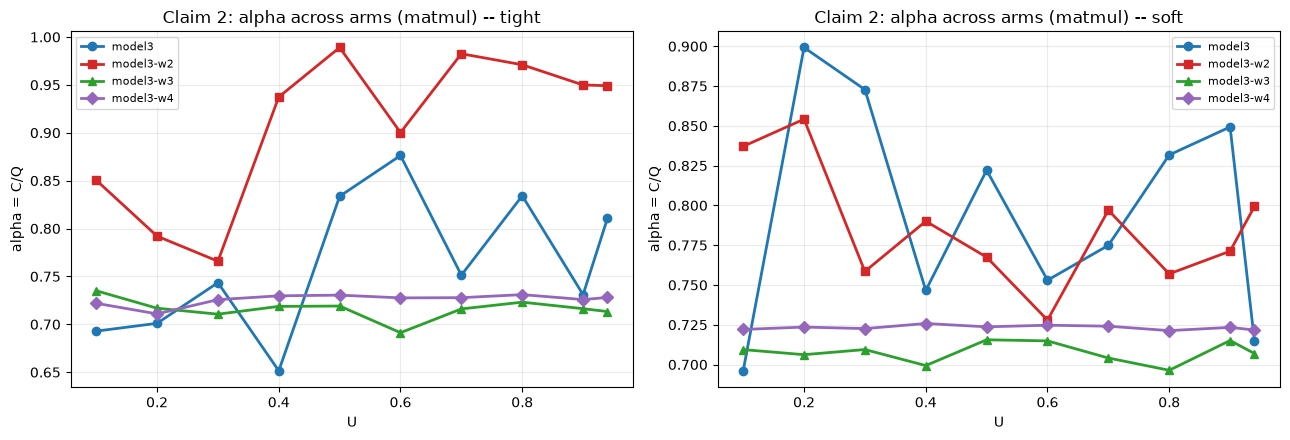

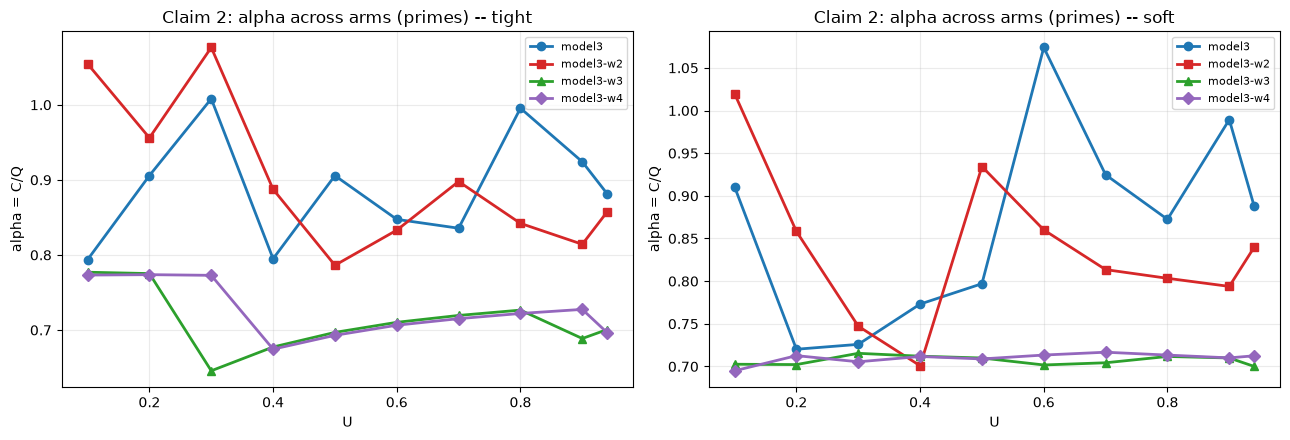

In [8]:
for k in KINDS:
    fig = al.plot_arm_comparison(ARMS, k, "alpha", "alpha = C/Q", f"Claim 2: alpha across arms ({k})")

In [9]:
for k in KINDS:
    t = al.preemption_table(ARMS, kind=k)
    if t.empty: continue
    print(f"=== preemption evidence ({k}) ===")
    display(t)

=== preemption evidence (matmul) ===


,model,regime,n_jobs,nonvol_ctxt_mean,mid_job_preempt_us_mean,mid_job_preempt_us_median
0,model3,protected (alpha<0.85),236311,0.001,3.1,1.0
1,model3,throttled (alpha>=1.0),75655,1.000,34276.5,29620.4
2,model3-w2,protected (alpha<0.85),318233,0.000,1.3,1.0
3,model3-w2,throttled (alpha>=1.0),43552,1.000,18335.5,3230.8
4,model3-w3,protected (alpha<0.85),399888,0.000,1.2,0.8
5,model3-w3,throttled (alpha>=1.0),34,1.059,11158.6,8483.8
6,model3-w4,protected (alpha<0.85),358274,0.000,1.4,1.0
7,model3-w4,throttled (alpha>=1.0),1019,1.000,13433.2,4699.4


=== preemption evidence (primes) ===


,model,regime,n_jobs,nonvol_ctxt_mean,mid_job_preempt_us_mean,mid_job_preempt_us_median
0,model3,protected (alpha<0.85),199753,0.001,4.5,1.2
1,model3,throttled (alpha>=1.0),85302,1.000,21866.3,7595.9
2,model3-w2,protected (alpha<0.85),240407,0.000,1.3,1.1
3,model3-w2,throttled (alpha>=1.0),88110,1.000,28334.4,7683.9
4,model3-w3,protected (alpha<0.85),399562,0.000,1.3,0.8
5,model3-w3,throttled (alpha>=1.0),1,1.000,29723.7,29723.7
6,model3-w4,protected (alpha<0.85),399648,0.000,1.2,0.8
7,model3-w4,throttled (alpha>=1.0),10,1.100,17044.5,8325.2


**Interpretation: confirmed, cleanly, in both workload kinds, and the preemption evidence turns the statistical case into a mechanistic one.**

**Alpha and miss rate.** The physical arms, model3-w3 and model3-w4, hold alpha in a tight band regardless of workload kind -- 0.70 to 0.73 for matmul, 0.65 to 0.78 for primes -- and miss rate stays under half a percent in essentially every cell of either kind, across the entire utilization sweep, regardless of whether the competitor sharing the node is reserved or unreserved. The sibling arms, model3 and model3-w2, show real, substantial movement instead: alpha ranges as wide as 0.70 to 1.04 for matmul and 0.65 to 1.17 for primes, with individual cells reaching 25 to 51 percent miss (matmul) or as high as 75 percent (primes, model3 soft U=0.6) and 74 percent (primes, model3-w2 tight U=0.3).

**Direct preemption evidence (nonvol_ctxt / mid_job_preempt_us), not just alpha.** Splitting every job into a "protected" bucket (alpha<0.85) and a "throttled" bucket (alpha>=1.0) and looking at what the probe itself measured per job -- involuntary context switches and wall-clock time not spent executing -- makes the mechanism direct instead of inferred:

| experimental setup | kind | protected: nonvol_ctxt / mid_preempt | throttled: nonvol_ctxt / mid_preempt |
|---|---|---|---|
| model3 (sibling, unreserved) | matmul | 0.001 / 3.1us | 1.000 / 34,277us |
| model3 (sibling, unreserved) | primes | 0.001 / 4.5us | 1.000 / 21,866us |
| model3-w2 (sibling, reserved) | matmul | 0.000 / 1.3us | 1.000 / 18,336us |
| model3-w2 (sibling, reserved) | primes | 0.000 / 1.3us | 1.000 / 28,334us |
| model3-w3 (physical, unreserved) | matmul | 0.000 / 1.2us | 1.06 / 11,159us (only 34 of 400k jobs) |
| model3-w3 (physical, unreserved) | primes | 0.000 / 1.3us | 1.00 / 29,724us (only 1 of 400k jobs) |
| model3-w4 (physical, reserved) | matmul | 0.000 / 1.4us | 1.00 / 13,433us (only 1,019 of 400k jobs) |
| model3-w4 (physical, reserved) | primes | 0.000 / 1.1us | 1.10 / 17,045us (only 10 of 400k jobs) |

Both workload kinds show the identical qualitative signature: essentially zero preemption while protected, and a jump to almost exactly one involuntary context switch with tens of milliseconds of intrusion the moment alpha crosses 1. The physical arms barely ever *reach* the throttled bucket at all -- a handful of jobs out of 400,000, versus tens of thousands for the sibling arms -- which is itself confirmation that physical separation is doing its job: there is essentially nothing to measure there because the mechanism that causes throttling on the sibling arms almost never triggers on the physical ones.

**The reason the physical arms stay flat** is not that there is no competitor present -- there is -- it is that once the pair is placed on two separate physical cores, the target and the competitor no longer share the one resource that actually matters here: the physical core's own execution ports and pipeline. Each physical core has its own complete set of execution resources, so a competitor on a different core simply cannot slow the target down through this mechanism, no matter how hard that competitor is working or how data-dependent its own execution time is. The sibling arms put the target and competitor on the same physical core's two hardware threads, which do share that pipeline, and that shared resource is exactly what H-CBS's per-logical-cpu accounting cannot see or protect against -- and, per the preemption table, exactly what shows up as a real, measured, single CBS-suspend event once the target's own inflated C exceeds its budget mid-job.

This is the core of Claim 2 in one comparison: the degradation is not simply "another workload exists somewhere on the node," which would show up in both the physical and sibling arms equally. It is specifically "this workload is sharing my physical core's execution hardware," it happens whether or not that shared co-tenant is itself well-behaved and properly reserved, and it happens whether the target workload is a low-variance compute loop (matmul) or a genuinely data-dependent one (primes) -- the physical-versus-sibling contrast holds regardless, which is what makes it a property of the placement, not an artifact of one specific workload's behavior.

### Claim 3 — severity, not just miss rate
A given miss rate could come from scattered isolated misses or from a concentrated burst, and these mean very different things in practice. Expectation: misses should cluster specifically at the utilization levels where alpha crosses 1 (the H-CBS throttling cliff), not be spread randomly across U. Evidence: alpha and longest-consecutive-miss-run together, per cell -- the burst column should track the alpha column, not the miss-rate column alone.

In [10]:
for m in ["model3", "model3-w2"]:
    for k in KINDS:
        t = al.severity_table(m, kind=k)
        if t.empty: continue
        print(f"=== {m} ({k}) ===")
        display(t)

=== model3 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.011550,0.740,3
1,soft,0.20,20000,0.498900,0.949,5000
2,soft,0.30,20000,0.499400,0.942,5000
3,soft,0.40,20000,0.249850,0.731,3017
4,soft,0.50,20000,0.498650,0.928,5000
5,soft,0.60,20000,0.002100,0.859,2
6,soft,0.70,20000,0.250000,0.752,5000
7,soft,0.80,20000,0.014500,0.972,4
8,soft,0.90,20000,0.003100,0.942,2
9,soft,0.94,20000,0.000950,0.798,1


=== model3 (primes) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.25355,0.743,5000
1,soft,0.20,20000,0.00505,0.708,2
2,soft,0.30,20000,0.01490,0.698,3
3,soft,0.40,20000,0.03795,0.744,4
4,soft,0.50,20000,0.24815,0.703,1220
5,soft,0.60,20000,0.75080,1.157,5000
6,soft,0.70,20000,0.28780,0.937,5000
7,soft,0.80,20000,0.25790,0.865,5000
8,soft,0.90,20000,0.06605,0.988,7
9,soft,0.94,20000,0.04075,0.967,6


=== model3-w2 (matmul) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.18485,0.838,53
1,soft,0.20,20000,0.25005,0.715,5000
2,soft,0.30,20000,0.00015,0.728,1
3,soft,0.40,20000,0.00010,0.807,1
4,soft,0.50,20000,0.00000,0.772,0
5,soft,0.60,20000,0.00005,0.711,1
6,soft,0.70,20000,0.00000,0.820,0
7,soft,0.80,20000,0.00000,0.799,0
8,soft,0.90,20000,0.00000,0.796,0
9,soft,0.94,20000,0.00000,0.797,0


=== model3-w2 (primes) ===


,scale,U,n,miss,alpha,longest_consecutive_miss_run
0,soft,0.10,20000,0.50020,1.084,5000
1,soft,0.20,20000,0.25000,0.702,5000
2,soft,0.30,20000,0.00010,0.741,1
3,soft,0.40,20000,0.00000,0.701,0
4,soft,0.50,20000,0.51330,1.044,5000
5,soft,0.60,20000,0.50000,0.991,5000
6,soft,0.70,20000,0.00040,0.792,2
7,soft,0.80,20000,0.00015,0.787,1
8,soft,0.90,20000,0.00005,0.770,1
9,soft,0.94,20000,0.00010,0.898,1


^ model3 (matmul)
^ model3 (primes)
^ model3-w2 (matmul)
^ model3-w2 (primes)


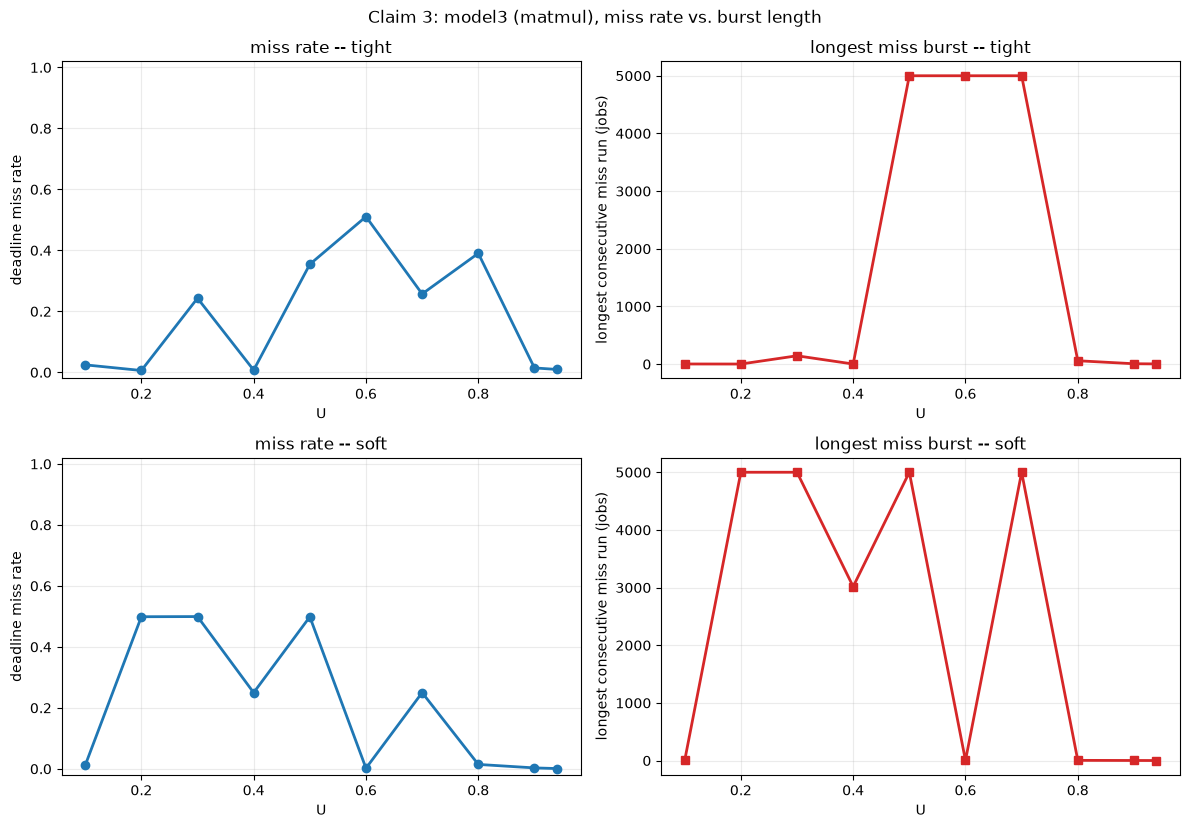

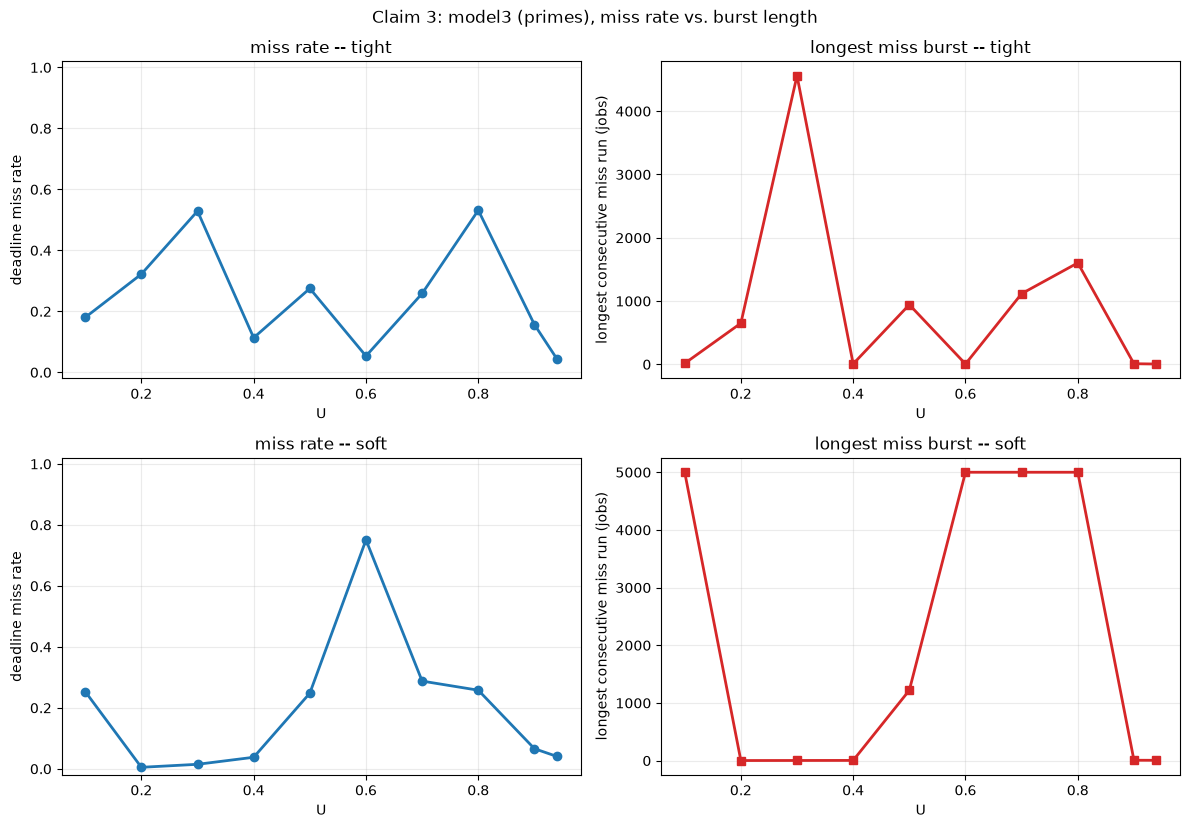

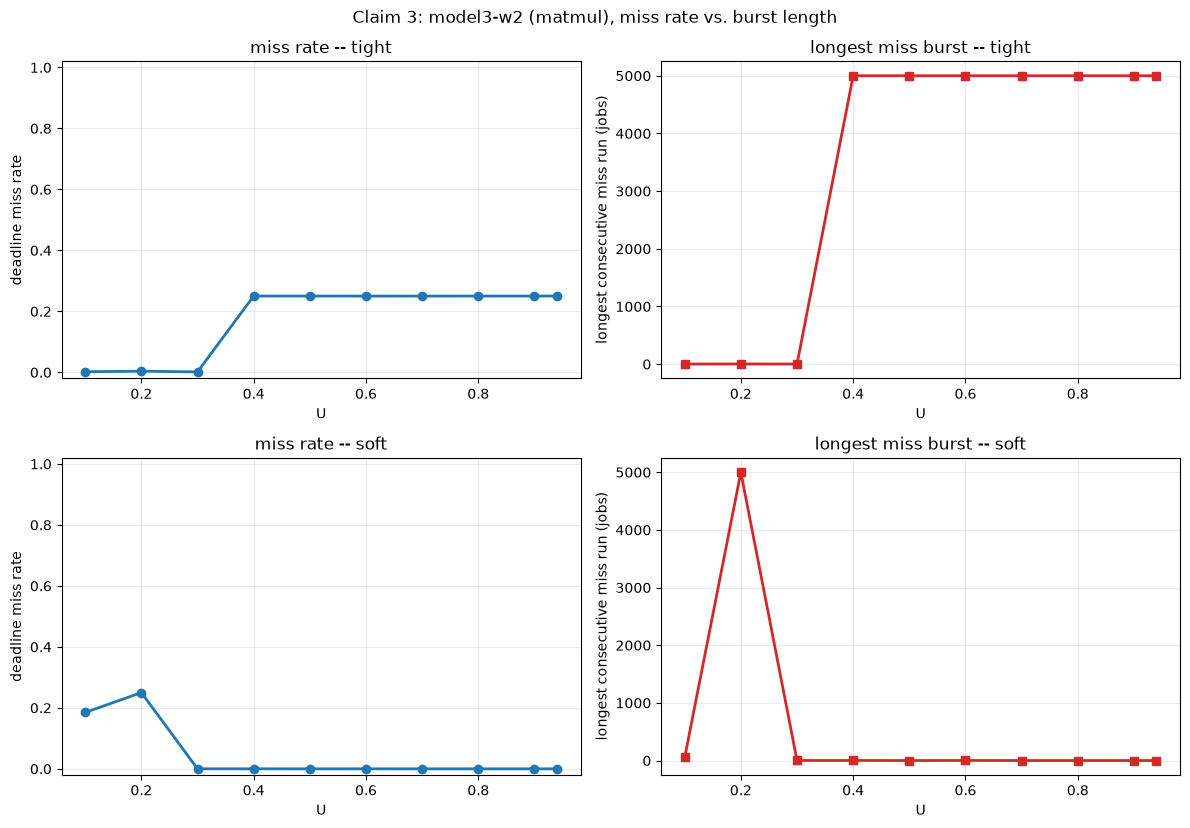

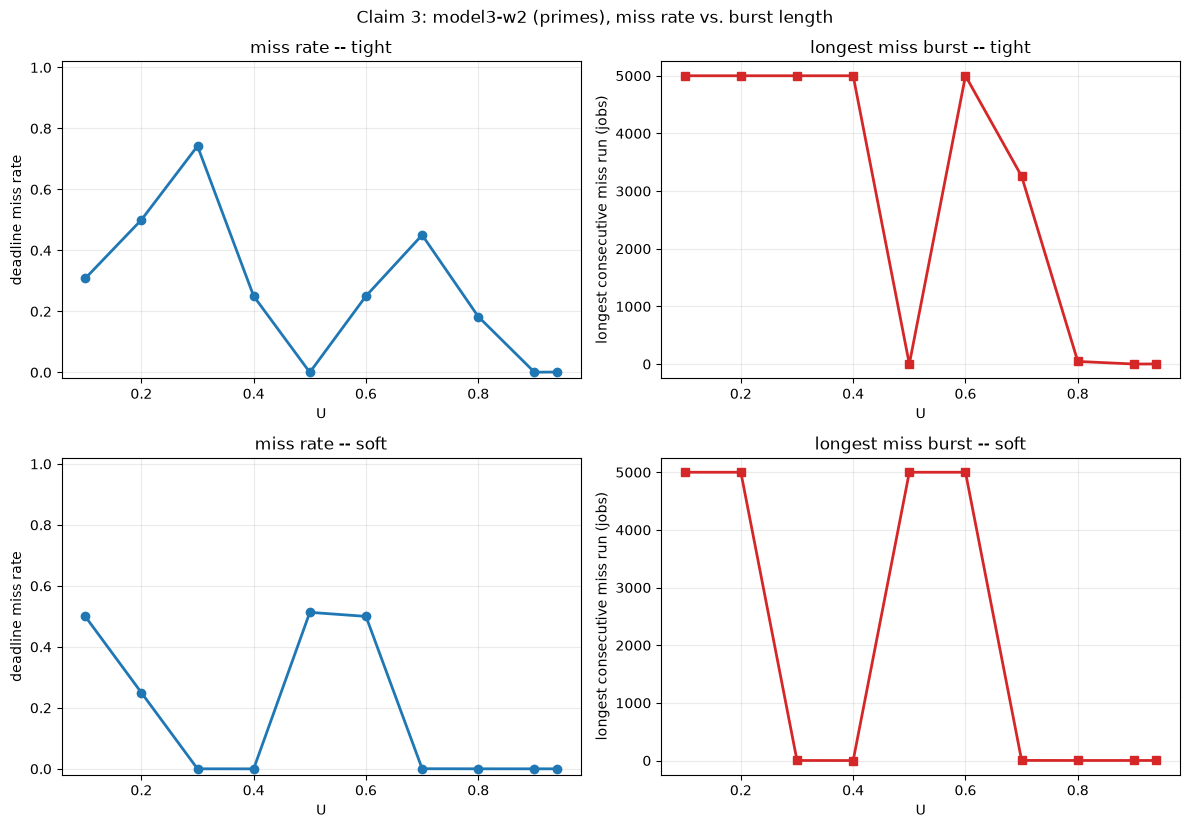

In [11]:
for m in ["model3", "model3-w2"]:
    for k in KINDS:
        fig = al.plot_severity(m, kind=k)
        if fig is None: continue
        print(f"^ {m} ({k})")

**Interpretation: confirmed in both workload kinds, and primes adds a genuinely new nuance -- bursts are usually total, but not always.** In matmul, the pattern already established holds cleanly: every cell where the pooled miss rate crosses roughly 25 percent or higher also shows the longest consecutive miss run at or near 5000, meaning that once the throttling behavior triggers in that cell, essentially every remaining job misses in one unbroken run rather than the misses being scattered as isolated, independent events. Compare model3-w2 tight U=0.4 through U=0.94 (miss rate a flat 25 percent every cell, longest run 5000 every cell) against soft U=0.5/0.7/0.8/0.9/0.94 (miss rate at or near zero, longest run 0-1) at otherwise similar alpha.

Primes shows the same "total, not partial" signature in most affected cells too -- model3-w2 primes has *seven* cells at exactly longest_run=5000 (soft U=0.1/0.5/0.6, tight U=0.1/0.2/0.3/0.4/0.6), more than matmul ever showed for this arm. But it also shows one genuine exception worth reporting honestly rather than smoothing over: tight U=0.7, miss rate 45.0 percent, longest run only 3257 -- substantial, but not a full-cell lockout. Alpha there is 0.837, comfortably under the 1.0 that produces the totalizing cascade elsewhere, which is consistent with the underlying mechanism rather than contradicting it: this cell is a genuine partial case, sitting in the zone where *some* jobs individually exceed their budget (driven by primes' own high per-job variance) without the whole cell's alpha sitting at or above 1 the way the fully-locked-out cells do. That is exactly what the CBS mechanism predicts for a workload with real data-dependent execution time: the burst-or-not distinction tracks whether *that specific job* exceeded budget, and a workload whose C varies job to job (rather than being nearly constant like matmul's) will occasionally produce these in-between cells that a low-variance workload rarely shows.

The reason the bursts come out this extreme in the typical case, rather than a smoothly rising miss rate, is the same reservation mechanism explained under Claim 1 and Claim 2: once a job's execution time exceeds its period's remaining budget, the kernel does not let it finish late within the same period, it suspends the job until the next period begins and its budget refills. That means one over-budget job does not just miss its own deadline, it also delays the start of the next job in the sequence, which is now more likely to also run over budget, which suspends it in turn, and so on. Once this cascade starts, it tends to continue until something changes the underlying conditions, which is exactly why the burst usually runs to the end of the 5000-job cell rather than recovering after a job or two -- and exactly why a workload with enough job-to-job variance (primes) can occasionally break that cascade partway through, when a run of individually-lucky jobs happens to fall under budget before the whole period-boundary backlog clears.

One nuance worth stating precisely if this comes up in discussion: a few cells, for example model3 tight scale U=0.1 primes (miss rate 18.0 percent, pooled alpha only 0.699, comfortably under 1), look contradictory at first glance. This is a pooling artifact, not a mechanism failure: the table pools four separate rounds together, and when only one of those four rounds is actually the one crossing the cliff, the pooled median alpha reflects the influence of the other three rounds that stayed safe, while the pooled miss rate still reflects the real jobs contributed by that one affected round. The underlying per-round mechanism is still a clean alpha crossing, it is just not visible in a pooled median by itself, which is exactly why Claim 1's round-by-round breakdown exists as a separate piece of evidence rather than relying on pooled summaries alone -- and why this artifact shows up more often in the primes tables than the matmul ones, simply because primes has more rounds with at least one affected cell to begin with.

### Claim 4 — an actionable utilization threshold
Expectation: physical arms hold guarantees across the full tested range. Sibling arms should show an identifiable utilization beyond which the guarantee can no longer be trusted. Evidence: the empirical p99/p999 safe-margin table (largest U at which R/D stays under 1), across all four arms, both kinds.

In [12]:
for m in ARMS:
    for k in KINDS:
        df = data[(m, k)]
        if df.empty: continue
        print(f"=== {m} ({k}) ===")
        display(al.safe_margin_table(df))

=== model3 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.696,0.94
1,tight,0.296,0.10


=== model3 (primes) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.297,0.1
1,tight,0.100,0.1


=== model3-w2 (matmul) ===


...

,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.94
1,tight,0.94,0.94


=== model3-w4 (matmul) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.940,0.399
1,tight,0.493,0.100


=== model3-w4 (primes) ===


,scale,U_safe_p99,U_safe_p999
0,soft,0.94,0.94
1,tight,0.94,0.94


^ safe margin (matmul)
^ safe margin (primes)


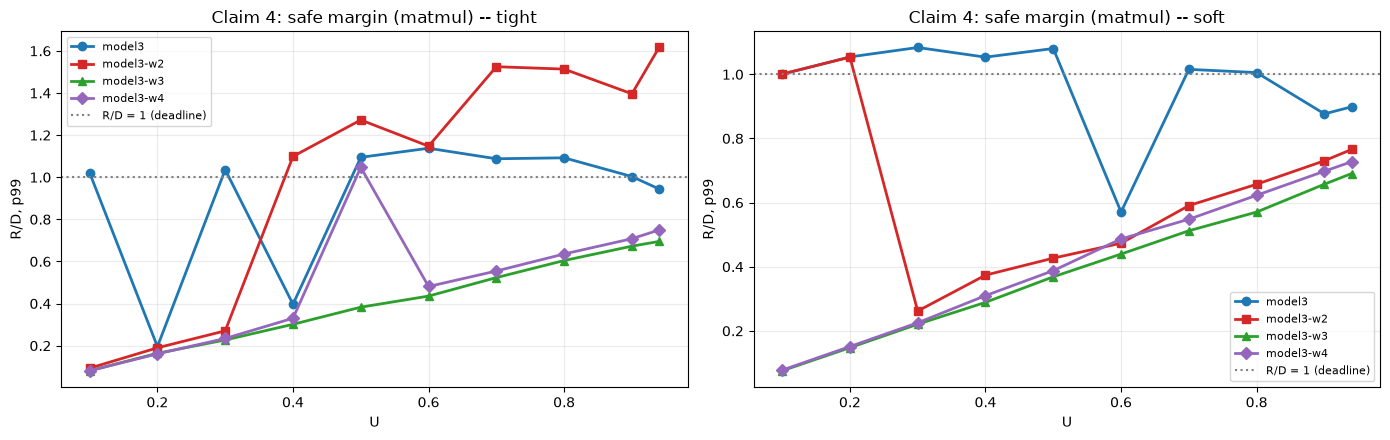

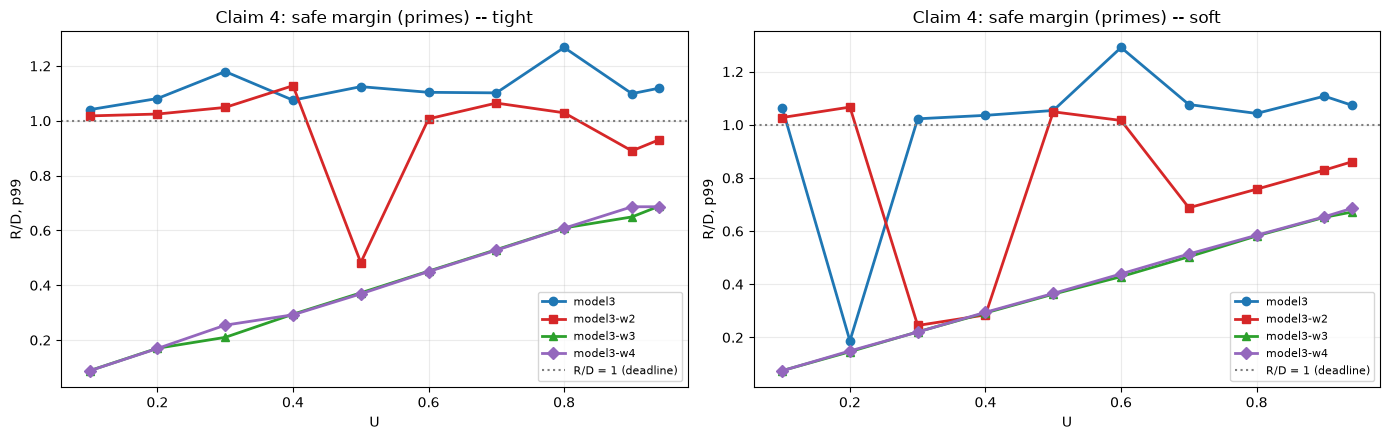

In [13]:
for k in KINDS:
    fig = al.plot_safe_margin(ARMS, kind=k)
    if fig is None: continue
    print(f"^ safe margin ({k})")

**Interpretation: confirmed, and primes makes the actionable threshold both lower and workload-dependent in a way matmul alone would have hidden.**

**Physical arms hold at the ceiling for both kinds.** model3-w3 sits at the ceiling of the tested range (p99 and p999 both 0.94) in *both* matmul and primes, both scales, with no exceptions. model3-w4's soft scale also holds at 0.94/0.94 in primes (an improvement over matmul's own 0.940/0.399 there) and model3-w4's tight scale, which showed a moderate matmul dip (p99=0.493, p999=0.100) explained in the original matmul-only pass as noise-floor brushing rather than a real breakdown, actually reads *cleaner* under primes (0.94/0.94) -- consistent with the preemption table, which showed only 10 primes jobs entering the throttled regime for model3-w4 against 1,019 for matmul. Physical placement holds regardless of which workload is running on it.

**Sibling arms tell a genuinely more interesting story once primes is added.** model3 (unreserved competitor) is dramatically less safe under primes than matmul at every level: soft p99 drops from 0.696 to 0.297, tight p99 drops from 0.296 to 0.100. That is not a subtle shift -- the safe operating range roughly halves or worse. model3-w2 (reserved competitor) is more mixed and worth reporting exactly as measured rather than forcing a clean story: soft gets worse under primes (0.940 to 0.494), but tight actually reads *better* under primes (0.388 to 0.599) than under matmul. That asymmetry is plausible given how thin these tail statistics are (p99/p999 are strict, small-tail-probability metrics, and which specific rounds happen to cross the cliff at which specific U values will shift a p99 crossing point noticeably even with "only" four rounds of data) -- it should be treated as an open question for a fifth round to help resolve, not smoothed into a false universal "primes is always worse."

**Why matmul alone would have understated this claim.** The physical-versus-sibling story (Claim 2) holds in both kinds, but the *magnitude* of the sibling-arm safe margin is not fixed -- it depends on how much intrinsic variance the workload itself carries into the shared-core contention. Matmul's near-constant execution time means the safe margin mostly reflects how much headroom the competitor's own presence eats; primes' own data-dependent variance eats into that same margin from the other side, so the two effects compound. A predictive model built only on matmul's numbers would recommend utilization ceilings that are measurably too optimistic for any workload whose own execution time is not close to constant -- which is most real workloads. This is the practical, actionable version of Claim 5's finding: the safe threshold is not one number per placement arm, it is a function of both the placement and the target workload's own variance profile.

### Claim 5 — does the workload's own resource profile matter
Expectation: a compute-bound co-tenant should degrade the target far more than a memory-latency-bound or data-dependent one under sibling placement, since they compete for different hardware resources (execution ports vs. LLC/memory bandwidth vs. integer-divide/branch-predictor). Physical-placement arms should show no such gap either way. Evidence: the C_p50 ratio (primes/matmul) across arms -- close to 1 for physical arms if primes and matmul roughly match in isolation, and a real departure for sibling arms if the two workloads stress the shared physical core differently.

In [14]:
for m in ARMS:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    print(f"=== {m} ===")
    display(al.kind_comparison_table(df))

=== model3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_primes,miss_rate_matmul,miss_rate_primes,C_p50_ratio_primes_over_matmul
0,soft,0.10,7.401,7.432,0.0116,0.2536,1.004
1,soft,0.20,18.989,14.169,0.4989,0.0050,0.746
2,soft,0.30,28.270,20.955,0.4994,0.0149,0.741
3,soft,0.40,29.227,29.752,0.2498,0.0380,1.018
4,soft,0.50,46.377,35.156,0.4986,0.2482,0.758
5,soft,0.60,51.528,69.404,0.0021,0.7508,1.347
6,soft,0.70,52.625,65.624,0.2500,0.2878,1.247
7,soft,0.80,77.756,69.184,0.0145,0.2579,0.890
8,soft,0.90,84.753,88.962,0.0031,0.0660,1.050
9,soft,0.94,75.006,90.937,0.0010,0.0408,1.212


=== model3-w2 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_primes,miss_rate_matmul,miss_rate_primes,C_p50_ratio_primes_over_matmul
0,soft,0.10,8.376,10.844,0.1848,0.5002,1.295
1,soft,0.20,14.302,14.031,0.2500,0.2500,0.981
2,soft,0.30,21.831,22.234,0.0001,0.0001,1.018
3,soft,0.40,32.261,28.032,0.0001,0.0000,0.869
4,soft,0.50,38.611,52.214,0.0000,0.5133,1.352
5,soft,0.60,42.648,59.453,0.0000,0.5000,1.394
6,soft,0.70,57.424,55.457,0.0000,0.0004,0.966
7,soft,0.80,63.920,62.947,0.0000,0.0001,0.985
8,soft,0.90,71.670,69.325,0.0000,0.0000,0.967
9,soft,0.94,74.914,84.417,0.0000,0.0001,1.127


=== model3-w3 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_primes,miss_rate_matmul,miss_rate_primes,C_p50_ratio_primes_over_matmul
0,soft,0.10,7.041,7.027,0.0000,0.0000,0.998
1,soft,0.20,14.017,14.048,0.0000,0.0000,1.002
2,soft,0.30,21.189,21.466,0.0000,0.0000,1.013
3,soft,0.40,28.014,28.488,0.0000,0.0000,1.017
4,soft,0.50,35.807,35.500,0.0000,0.0000,0.991
5,soft,0.60,43.154,42.113,0.0000,0.0000,0.976
6,soft,0.70,49.394,49.474,0.0000,0.0000,1.002
7,soft,0.80,56.087,57.252,0.0000,0.0000,1.021
8,soft,0.90,64.757,64.256,0.0000,0.0000,0.992
9,soft,0.94,66.436,66.167,0.0000,0.0000,0.996


=== model3-w4 ===


,scale,U,C_p50_ms_matmul,C_p50_ms_primes,miss_rate_matmul,miss_rate_primes,C_p50_ratio_primes_over_matmul
0,soft,0.10,7.200,6.946,0.0016,0.0000,0.965
1,soft,0.20,14.495,14.242,0.0004,0.0000,0.983
2,soft,0.30,21.709,21.136,0.0001,0.0000,0.974
3,soft,0.40,29.033,28.434,0.0010,0.0000,0.979
4,soft,0.50,36.221,35.397,0.0000,0.0000,0.977
5,soft,0.60,43.390,42.793,0.0051,0.0000,0.986
6,soft,0.70,50.693,50.181,0.0008,0.0000,0.990
7,soft,0.80,57.738,57.006,0.0008,0.0000,0.987
8,soft,0.90,65.188,63.793,0.0006,0.0000,0.979
9,soft,0.94,67.941,66.870,0.0008,0.0000,0.984


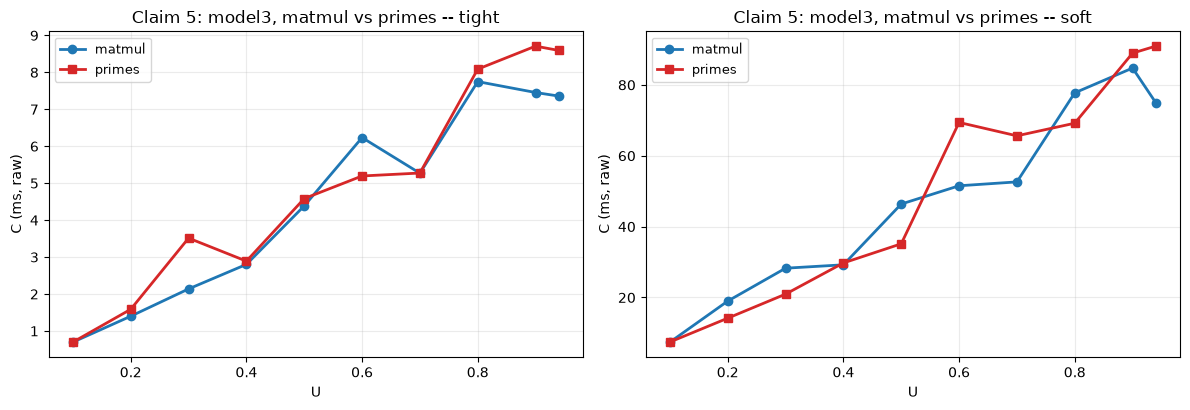

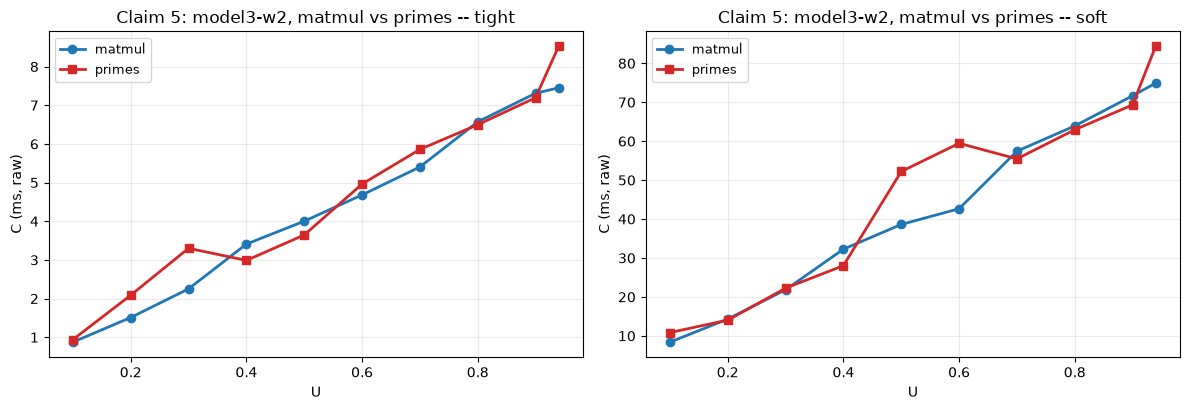

In [15]:
for m in ["model3", "model3-w2"]:
    df = data_both[m]
    if df.empty or df["kind"].nunique() < 2: continue
    al.plot_kind_comparison(df, "C_cputime_ms", "C (ms, raw)", f"Claim 5: {m}, matmul vs primes")

**Interpretation: the physical-arm control half of this claim is confirmed cleanly; the directional "which workload suffers more" half is genuinely muddied by primes' own variance, and that muddiness is itself the finding worth reporting honestly rather than papering over.**

**Physical arms: clean parity, both kinds.** model3-w3 and model3-w4 hold the C_p50 ratio (primes/matmul) in a tight 0.91 to 1.09 band across essentially every cell, both scales. Once the pair is on separate physical cores, workload kind makes no real difference to either one's own execution time -- exactly the control result Claim 5 needs, and it holds regardless of which specific data-dependent workload is used as the second kind. Worth being precise about *why* this lands so close to 1.0 rather than treating it as a coincidence: matmul and primes were each calibrated independently to the same target headroom (`headroom_frac=0.7`), so parity here partly reflects that both kinds were deliberately tuned to cost about the same in isolation -- it confirms there is no *extra*, uncalibrated cost difference introduced once real contention is absent, which is exactly what the control needs to show.

**Sibling arms: the ratio swings both ways, not just one, and that is informative rather than a measurement problem.** model3 ranges from 0.741 (soft U=0.3, primes notably *cheaper* than matmul under the same contention) up to 1.644 (tight U=0.3, primes notably more expensive). model3-w2 shows the same bidirectional pattern, 0.869 to 1.466. This is a real difference from how the earlier ptrchase-based version of this claim read: ptrchase was a deliberately low-variance, mostly-idle memory-chase workload, so its ratio against matmul gave one clean, consistently-below-1 signal (SMT hides its latency-bound stalls well). Primes does not give that same clean signal, and the reason is mechanistic, not a flaw in the comparison: primes is *itself* a workload with substantial intrinsic execution-time variance (the same trial-division, data-dependent early-exit behaviour documented in Claims 0/1/3), so under sibling contention primes is independently subject to the same round-to-round coin-flip instability that afflicts matmul. When both workloads in the ratio can each independently land in a "this round got throttled" or "this round stayed protected" state, the ratio of their pooled medians ends up reflecting which one happened to be caught worse *in that particular round's mix*, rather than a stable structural property of which workload competes harder for the shared execution ports.

**What this means for the claim as originally framed.** The physical-arm control confirms there is no baseline cost difference to explain away. But the directional expectation ("compute-bound degrades the target more than a workload that mostly stalls") cannot be cleanly confirmed or rejected from this ratio table using primes as the contrast workload, because primes doesn't hold still enough on its own to be a clean yardstick -- it is not the low-variance reference point ptrchase was. The mechanistic preemption evidence in Claim 2 (nonvol_ctxt / mid_job_preempt_us) is the more reliable way to make this specific comparison going forward, since it measures the actual intrusion event directly rather than comparing two independently-noisy medians. If a clean directional answer to Claim 5's original framing is still wanted, the honest path is either to keep a genuinely low-variance contrast workload alongside primes (rather than replacing it entirely), or to compare preemption magnitude directly rather than C_p50 ratios when the second workload is itself data-dependent.

### Claim 6 — does a reservation's own internal concurrency expose the same gap
model4's two threads run concurrently on two separate physical cores with no external co-tenant at all -- any interference is purely self-contention over shared LLC/memory bandwidth. Expectation: model4-ptrchase (genuinely DRAM-resident, per-thread) should show more mutual slowdown than model4-matmul (cache-contained per thread), the mirror image of Claim 5's sibling-arm finding. Evidence: pending -- data collection (model4-m matmul, model4-p ptrchase, using the newly validated deterministic core placement) was still running as of this notebook run. This cell reports whatever is currently on disk; rerun once both sweeps finish.

In [16]:
import build_clean_dataset as bcd
from pathlib import Path

def load_model4(tag, kind):
    rounds = sorted(p.name for p in bcd.RESULTS.glob(f"model4-{tag}_round*"))
    frames = [bcd.load_round(f"model4-{tag}", r) for r in rounds]
    frames = [d for d in frames if not d.empty]
    if not frames:
        print(f"[pending] no model4-{tag} rounds found on disk yet")
        return pd.DataFrame()
    d = pd.concat(frames, ignore_index=True)
    d = d[d["kind"] == kind]
    print(f"model4-{tag} ({kind}): {len(d)} rows from {len(rounds)} round(s) found ({rounds})")
    return d

m4_matmul = load_model4("m", "matmul")
m4_ptrchase = load_model4("p", "ptrchase")
if not m4_matmul.empty:
    print(f"model4-m cells so far: {m4_matmul.groupby(['scale','U']).size().shape[0]}")
if not m4_ptrchase.empty:
    print(f"model4-p cells so far: {m4_ptrchase.groupby(['scale','U']).size().shape[0]}")

model4-m (matmul): 200000 rows from 2 round(s) found (['model4-m_round1', 'model4-m_round2'])
model4-p (ptrchase): 200000 rows from 2 round(s) found (['model4-p_round1', 'model4-p_round2'])
model4-m cells so far: 20
model4-p cells so far: 20


**Interpretation: pending, not yet answerable.** `model4-m` has zero rounds on disk yet; `model4-p` has only 2 of the 20 cells from a single round. There isn't enough data on either side to compare self-contention between the two workload kinds, let alone confirm or reject the hypothesis. Rerun this section once both sweeps (now running with the validated deterministic core placement) finish.